In [21]:
from collections import namedtuple
from os import W_OK
from pathlib import Path
from fluids.atmosphere import ATMOSPHERE_1976

import openvsp as vsp
vsp.InitGUI()
vsp.StartGUI()

vsp_file = Path('./wing_assignment.vsp3')
aero_path = Path('~/Downloads/OpenVSP-3.46.0-win64').expanduser()

vsp.VSPCheckSetup()  # Verify everything is working as expected
vsp.VSPRenew()  # Clear all global state
vsp.ClearVSPModel()
vsp.Update()

vsp.SetVSPAEROPath(str(aero_path))

# read vsp3 input file
vsp.ReadVSPFile(str(vsp_file))
vsp.Update()

analysis_name = "VSPAEROComputeGeometry"
vsp.SetAnalysisInputDefaults(analysis_name)
vsp.PrintAnalysisInputs(analysis_name)
vsp.ExecAnalysis(analysis_name)

analysis_name = "VSPAEROSweep"
vsp.SetAnalysisInputDefaults(analysis_name)
vsp.SetDoubleAnalysisInput(analysis_name, "AlphaEnd", (float(15),), 0)
n_pts = vsp.GetIntAnalysisInput(analysis_name, "AlphaNpts")
vsp.Update()
# # vsp.PrintAnalysisInputs(analysis_name)
vsp.ExecAnalysis(analysis_name)


'YDTAXBF'

In [50]:
n_pts

(20,)

In [51]:
history_res = vsp.FindResultsID("VSPAERO_History", 2)
CL = vsp.GetDoubleResults(history_res, "CLtot", 0)
CL = [vsp.GetDoubleResults(vsp.FindResultsID("VSPAERO_History", x), "CLtot", 0)[-1] for x in range(0, n_pts[0])]
CD = [vsp.GetDoubleResults(vsp.FindResultsID("VSPAERO_History", x), "CDtot", 0)[-1] for x in range(0, n_pts[0])]

In [53]:
Alphas = [vsp.GetDoubleResults(vsp.FindResultsID("VSPAERO_History", x), "Alpha", 0)[-1] for x in range(0, n_pts[0])]

<module 'matplotlib.pyplot' from 'C:\\Users\\ysuho\\anaconda3\\envs\\vsppytools\\Lib\\site-packages\\matplotlib\\pyplot.py'>

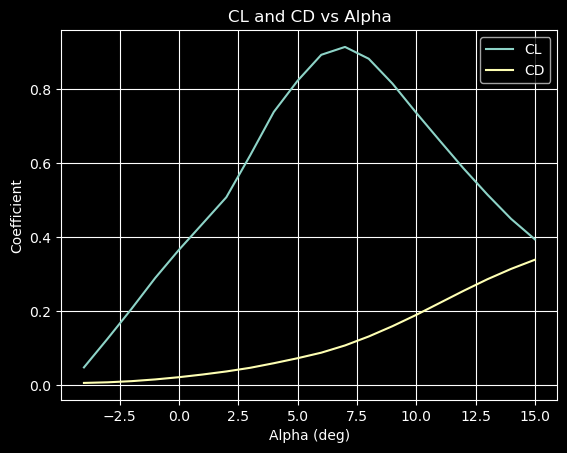

In [55]:
import matplotlib.pyplot as plt

plt.plot(Alphas, CL, label="CL")
plt.plot(Alphas, CD, label="CD")
plt.xlabel("Alpha (deg)")
plt.ylabel("Coefficient")
plt.title("CL and CD vs Alpha")
plt.legend()
plt.grid()
plt

In [82]:
analysis_name = "VSPAEROSweep"
vsp.SetAnalysisInputDefaults(analysis_name)
vsp.GetIntAnalysisInput(analysis_name, "NumWakeNodes")

In [4]:
import openvsp as vsp
from pathlib import Path
vsp_file = Path('./wing_assignment.vsp3')
aero_path = Path('~/Downloads/OpenVSP-3.46.0-win64').expanduser()

vsp.SetVSPAEROPath(str(aero_path))

# read vsp3 input file
vsp.ReadVSPFile(str(vsp_file))
vsp.Update()

In [31]:
geom = vsp.FindGeomsWithName("WingGeom")[0]

xsec_surf = vsp.GetXSecSurf(geom, 0)
# IDK why there are two sections even though there is only one in the GUI
# The first one is default?
xsec = vsp.GetXSec(xsec_surf, 1)
sec_tess_u = vsp.GetXSecParm(xsec, 'SectTess_U')

vsp.GetIntParmVal(sec_tess_u)


sec_tess_w = [x for x in vsp.GetGeomParmIDs(geom) if vsp.GetParmName(x) == 'SectTess_U'][0]

vsp.GetIntParmVal(sec_tess_w)


6

In [29]:
vsp.GetAnalysisInputNames("VSPAEROSweep")

('2DFEMFlag',
 'AdjointGMRESConvergenceFactor',
 'AlphaEnd',
 'AlphaNpts',
 'AlphaStart',
 'AutoTimeNumRevs',
 'AutoTimeStepFlag',
 'BetaEnd',
 'BetaNpts',
 'BetaStart',
 'CGDegenSet',
 'CGGeomSet',
 'CGModeID',
 'CLMax2D',
 'Clo2D',
 'CoreSizeFactor',
 'FarAway',
 'FarDist',
 'FarDistToggle',
 'FixedWakeFlag',
 'ForwardGMRESConvergenceFactor',
 'FreezeMultiPoleAtIteration',
 'FreezeWakeAtIteration',
 'FreezeWakeRootVortices',
 'FromSteadyState',
 'GeomSet',
 'GroundEffect',
 'GroundEffectToggle',
 'HoverRamp',
 'HoverRampFlag',
 'ImplicitWake',
 'ImplicitWakeStartIteration',
 'MACFlag',
 'MachEnd',
 'MachNpts',
 'MachStart',
 'Machref',
 'ManualVrefFlag',
 'MassSliceDir',
 'ModeID',
 'NCPU',
 'NoiseCalcFlag',
 'NoiseCalcType',
 'NoiseUnits',
 'NonLinearConvergenceFactor',
 'NumMassSlice',
 'NumTimeSteps',
 'NumWakeNodes',
 'PropBladesMode',
 'QuadTreeBufferLevels',
 'ReCref',
 'ReCrefEnd',
 'ReCrefNpts',
 'RedirectFile',
 'RefFlag',
 'Rho',
 'ScurveFlag',
 'Sref',
 'StallModel',
 'Sta